### Imports

In [80]:
import sklearn as sk
import gensim as gsn
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.model_selection import train_test_split
import pyLDAvis as vis

### Load & split data

In [81]:
path = os.getcwd()
df = pd.read_csv(path + "/data/processed_data.csv", sep=";")
partis_corres = pd.read_csv(path + "/data/partis_correspondance.csv", sep=";")
df = pd.merge(df, partis_corres, how="inner", left_on='titulaire-soutien', right_on='parti')

In [82]:
df_train, df_test = train_test_split(df, test_size=0.2, train_size=0.8)

### Count Vectorizer

In [83]:
stopwords = [x.strip() for x in open('data/stop_words_copy.txt').readlines()]
vectorizer = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
vectorizer.fit(df_train['text'].to_list())
df_train_counts = vectorizer.transform(df_train['text'])
df_test_counts = vectorizer.transform(df_test['text'])

vocab = vectorizer.vocabulary_.keys()

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


In [84]:
train_split = df_train['text'].apply(lambda x: x.split())
doc_lengths = train_split.apply(lambda x: len(x)).to_list()

### LDA

In [85]:
lda = LDA(n_components=10, max_iter=5, random_state=0)
lda.fit(df_train_counts)
topic_term_dists = lda.components_

In [86]:
doc_topic_dists = lda.transform(df_train_counts)

### Visualization

In [87]:
term_frequency = np.array(np.sum(df_train_counts, axis =0)).flatten()

In [88]:
lda_data = {'topic_term_dists': topic_term_dists,
            'doc_topic_dists' : doc_topic_dists,
            'doc_lengths' : doc_lengths,
             'vocab' : vocab,
             'term_frequency' : term_frequency}

lda_viz = vis.prepare(**lda_data)


In [89]:
vis.display(lda_viz)

In [90]:
#modèles pour chaque groupes
dict = {}
for groupe in df['groupe'].unique():
    print(groupe)
    df_groupe = df[df['groupe'] == groupe]
    vectorizer_groupe = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
    vectorizer_groupe.fit(df_groupe['text'].to_list())
    df_groupe_counts = vectorizer_groupe.transform(df_groupe['text'])
    lda_groupe = LDA(n_components=6 , max_iter=30, random_state=0)
    lda_groupe.fit(df_groupe_counts)
    dict[groupe] = (vectorizer_groupe, lda_groupe)

Indépendant/micro-partis


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Extrême-gauche


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Gauche


...

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Régionaliste/Autonomiste


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Action spécifique
Ecologiste


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(
c:

In [94]:
def top_mots(group , nb_mots=3):
    output = []
    model = dict[group][1]
    features = dict[group][0].get_feature_names_out()
    for _, topic in enumerate(model.components_): # compose output message with top words
        output.append([(features[i], topic[i]) for i in topic.argsort()[:-nb_mots - 1:-1]])# [start (0 if omitted): end : slicing increment]
    return output

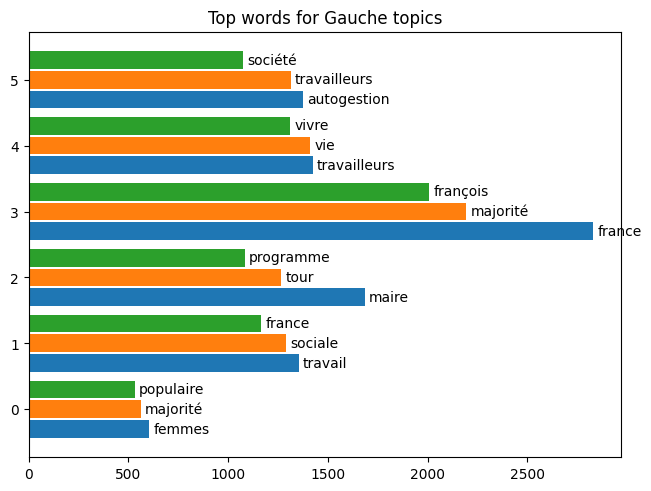

In [95]:
group = "Gauche"

nb_mots = 3
mots = top_mots(group, nb_mots)
nb_topic = len(mots)

y = np.arange(nb_topic)  # the label locations
width = 0.3  # the width of the bars
multiplier = -1

fig, ax = plt.subplots(layout='constrained')

x = [[mots[t][i] for t in range(nb_topic)] for i in range(nb_mots)]
for n in range(nb_mots):
    words = [x[n][i][0] for i in range(nb_topic)]
    proba = [x[n][i][1] for i in range(nb_topic)]
    
    offset = width * multiplier
    rects = ax.barh(y + offset, proba, width*0.9, label=words)
    ax.bar_label(rects, labels=words, padding=3)
    multiplier += 1

ax.set_title('Top words for ' + group + ' topics')
plt.yticks(np.arange(nb_topic))

plt.show()

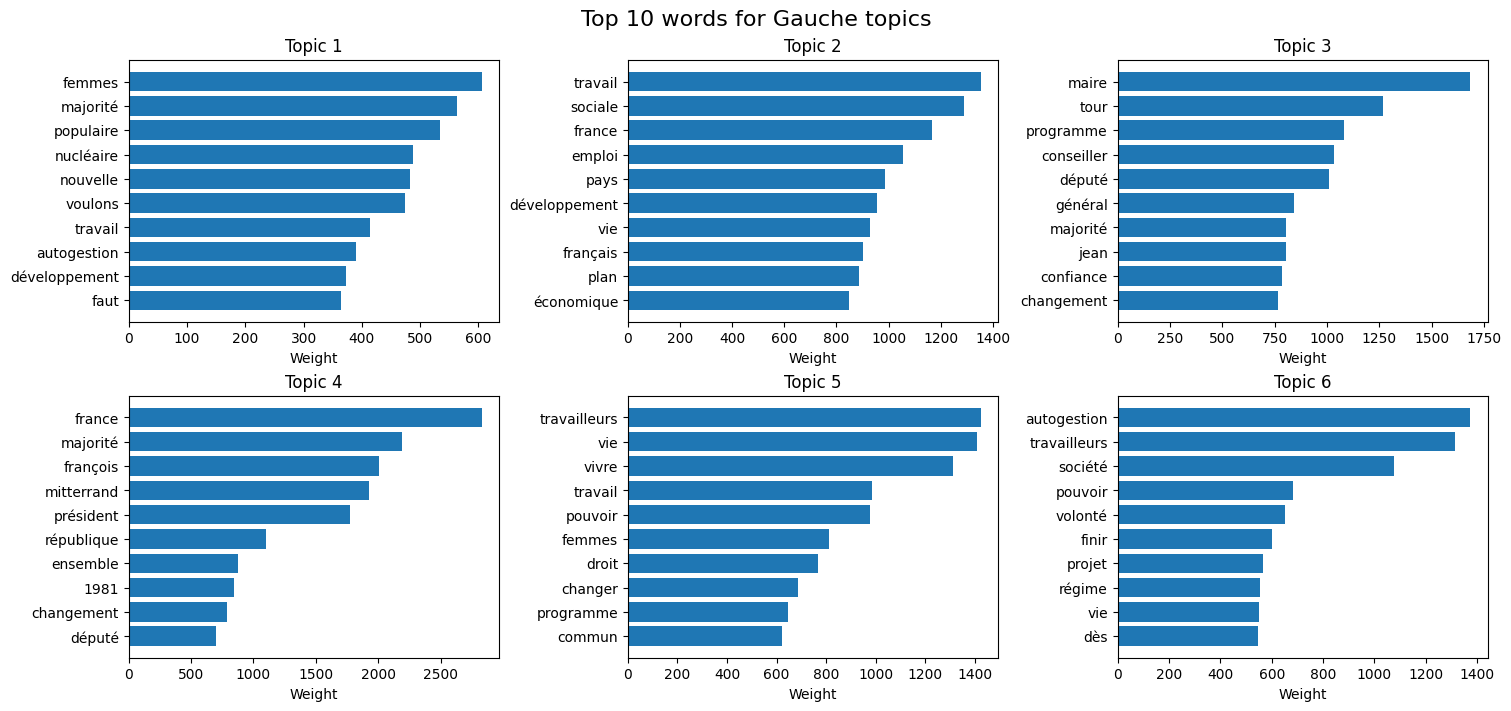

In [96]:
group = "Gauche"
nb_mots = 10

mots = top_mots(group, nb_mots=nb_mots)
nb_topic = len(mots)

# Number of columns in the subplot grid
n_cols = 3
n_rows = int(np.ceil(nb_topic / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 3.5 * n_rows),
    layout="constrained"
)

axes = np.array(axes).reshape(-1)

for topic_id, topic_words in enumerate(mots):
    ax = axes[topic_id]
    
    words = [word for word, weight in topic_words]
    weights = [weight for word, weight in topic_words]
    
    y = np.arange(len(words))
    
    ax.barh(y, weights)
    ax.set_yticks(y)
    ax.set_yticklabels(words)
    ax.invert_yaxis()
    
    ax.set_title(f"Topic {topic_id + 1}")
    ax.set_xlabel("Weight")

# Remove empty subplots if needed
for i in range(nb_topic, len(axes)):
    fig.delaxes(axes[i])

fig.suptitle(f"Top {nb_mots} words for {group} topics", fontsize=16)

plt.show()

In [97]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# Modèles NMF pour chaque groupe politique
dict_nmf = {}

for groupe in df['groupe'].unique():
    print(groupe)
    
    df_groupe = df[df['groupe'] == groupe]
    
    vectorizer_groupe = TfidfVectorizer(
        max_features=200,
        max_df=0.95,
        min_df=2,
        stop_words=stopwords
    )
    
    df_groupe_tfidf = vectorizer_groupe.fit_transform(df_groupe['text'].to_list())
    
    nmf_groupe = NMF(
        n_components=6,
        max_iter=300,
        random_state=0,
        init='nndsvda'
    )
    
    nmf_groupe.fit(df_groupe_tfidf)
    
    dict_nmf[groupe] = (vectorizer_groupe, nmf_groupe)

Indépendant/micro-partis


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Extrême-gauche


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Gauche


...

c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Extrême-droite


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Centre droit
Régionaliste/Autonomiste
Action spécifique
Ecologiste


c:\Users\mathi\OneDrive\Documents\Mathis\ENSAE\3e_annee\NLP\NLP\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'ant', 'ante', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'supplã', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(
c:

In [101]:
def plot_nmf_topics(group, nb_mots=10, n_cols=3):
    mots = top_mots_nmf(group, nb_mots=nb_mots)
    nb_topic = len(mots)

    n_rows = int(np.ceil(nb_topic / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        layout="constrained"
    )

    axes = np.array(axes).reshape(-1)

    for topic_id, topic_words in enumerate(mots):
        ax = axes[topic_id]

        words = [word for word, weight in topic_words]
        weights = [weight for word, weight in topic_words]

        y = np.arange(len(words))

        ax.barh(y, weights)
        ax.set_yticks(y)
        ax.set_yticklabels(words)
        ax.invert_yaxis()

        ax.set_title(f"Topic {topic_id + 1}")
        ax.set_xlabel("Weight")

    for i in range(nb_topic, len(axes)):
        fig.delaxes(axes[i])

    fig.suptitle(f"Top {nb_mots} words for {group} NMF topics", fontsize=16)

    plt.show()

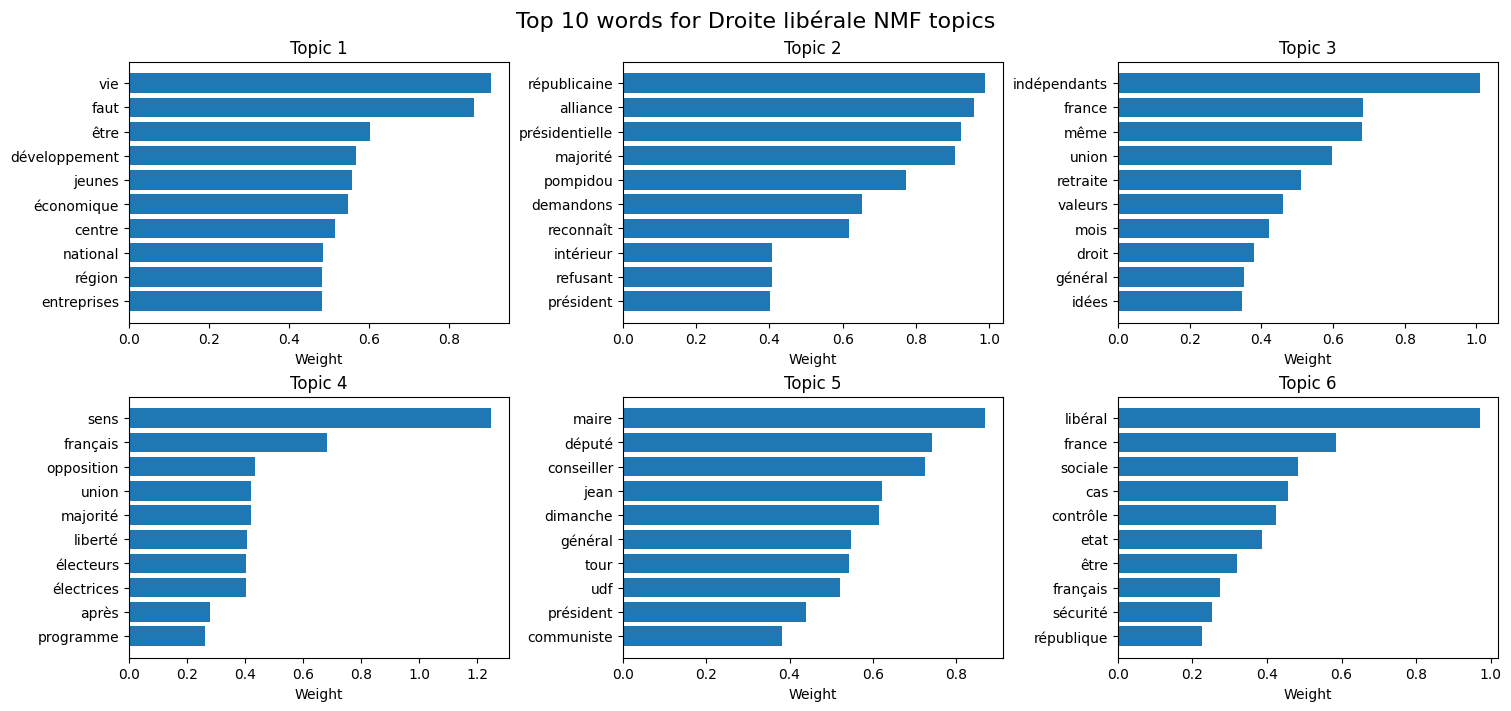

In [104]:
plot_nmf_topics("Droite libérale", nb_mots=10)